# Wind capacity factor composites

In [1]:
# client.close()
# cluster.close()

In [2]:
from dask.distributed import Client,LocalCluster
from dask_jobqueue import PBSCluster

In [3]:
PROJECT = "dt6"

In [4]:
walltime = "01:00:00"
cores = 24
memory = str(4 * cores) + "GB"

cluster = PBSCluster(
    walltime=str(walltime),
    cores=cores,
    memory=str(memory),
    processes=cores,
    job_extra_directives=[
        "-q normal",
        "-P "+PROJECT,
        "-l ncpus="+str(cores),
        "-l mem="+str(memory),
        "-l storage=gdata/xp65+gdata/w42+scratch/w42+gdata/gb02+scratch/gb02+gdata/ng72+scratch/ng72+gdata/rt52"
    ],
    local_directory="$TMPDIR",
    job_directives_skip=["select"],
    log_directory="/scratch/w42/dr6273/tmp/logs"
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36145 instead
  warnings.warn(


In [5]:
cluster.scale(jobs=1)
client = Client(cluster)

In [6]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /proxy/36145/status,
Dashboard: /proxy/36145/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.6.121.13:42121,Workers: 0
Dashboard: /proxy/36145/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [7]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [8]:
%cd /g/data/w42/dr6273/work/hot-cloudy/

/g/data/w42/dr6273/work/hot-cloudy


In [9]:
events = pd.read_csv(
    "hot_cloudy_2015_2024/event_dates_csi0p5_thourly90_counts.csv",
    parse_dates=True,
    index_col=0
)

In [10]:
nulls = pd.read_csv(
    "hot_cloudy_2015_2024/null_event_dates_csi0p5_thourly90_nhours7.csv",
    parse_dates=True,
    index_col=0
)

In [11]:
len(events)

312

In [12]:
len(nulls)

240

In [13]:
def get_yearly_wind(year):
    """
    Return array of wind speed for a desired year

    year: int
    """
    wind_path = "/scratch/w42/dr6273/BARRA-C2/derived/wind_speed/w100m/"
    return xr.open_zarr(
            wind_path+"w100m_BARRA-C2_20min_"+str(year)+".zarr",
            consolidated=True
        )["w100m"]

In [14]:
def get_date_wind(date):
    """
    Return array of wind speed for a single date, 1000-1600 AEST

    date: pandas Timestamp
    """
    # Open zarr store for desired year
    year = date.year
    wind = get_yearly_wind(year)

    # Select 0000-0600 UTC for date (corresponds to 1000-1600 AEST)
    end = date + pd.DateOffset(hour=6, minute=45)
    wind = wind.sel(time=slice(date, end))
    
    return wind

In [15]:
def get_all_dates_wind(dates):
    """
    Return concatenated array of wind speed for all dates

    dates: pandas DateTimeIndex
    """
    da_list = []
    for date in dates:
        wind = get_date_wind(date)
        da_list.append(wind)
    return xr.concat(da_list, dim="time")

In [16]:
def capacity_factor(W):
    """
    Computes capacity factor from wind speed data.
    
    W: wind speed (m/s)
    """
    W_0 = 3.5 # cut-in speed (m/s)
    W_r = 13 # rated speed
    W_1 = 25 # cut-out speed (m/s)
    
    # Cubic
    c_f = (W ** 3 - W_0 ** 3) / (W_r ** 3 - W_0 ** 3)
    c_f = c_f.where(W >= W_0, 0) # Set values below cut-in to zero
    c_f = c_f.where(W < W_r, 1) # Set values above rated speed to 1
    c_f = c_f.where(W < W_1, 0) # Set values above cut-off to zero
    c_f = c_f.where(W.notnull(), np.nan) # Ensure NaNs are retained
    
    return c_f

### Process for all regions

In [17]:
regions = np.unique(events["region"])

In [18]:
regions

array(['ACTE', 'GADE', 'GBRI', 'GHOB', 'GMEL', 'GSYD'], dtype=object)

In [19]:
# If we need to compute the composites
compute = False

In [22]:
composite_data = {}
for region in regions:
    composite_data[region] = {}

    if compute:
        # Event/null event days for region
        r_events = events[events["region"] == region]
        r_nulls = nulls[nulls["region"] == region]
    
        # Wind speed data
        r_wind_events = get_all_dates_wind(r_events.index)
        r_wind_nulls = get_all_dates_wind(r_nulls.index)
    
        # Capacity factors
        r_cf_events = capacity_factor(r_wind_events)
        r_cf_nulls = capacity_factor(r_wind_nulls)

        # Time-mean
        r_cf_events = r_cf_events.mean("time")
        r_cf_nulls = r_cf_nulls.mean("time")

        # Write to file
        r_cf_events.to_netcdf(
            "hot_cloudy_2015_2024/wind_capacity_factor_composite_events_"+region+".nc"
        )
        r_cf_nulls.to_netcdf(
            "hot_cloudy_2015_2024/wind_capacity_factor_composite_null_events_"+region+".nc"
        )

    # Read in composite data
    composite_data[region]["events"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/wind_capacity_factor_composite_events_"+region+".nc"
    )["w100m"]
    composite_data[region]["nulls"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/wind_capacity_factor_composite_null_events_"+region+".nc"
    )["w100m"]

In [25]:
import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'

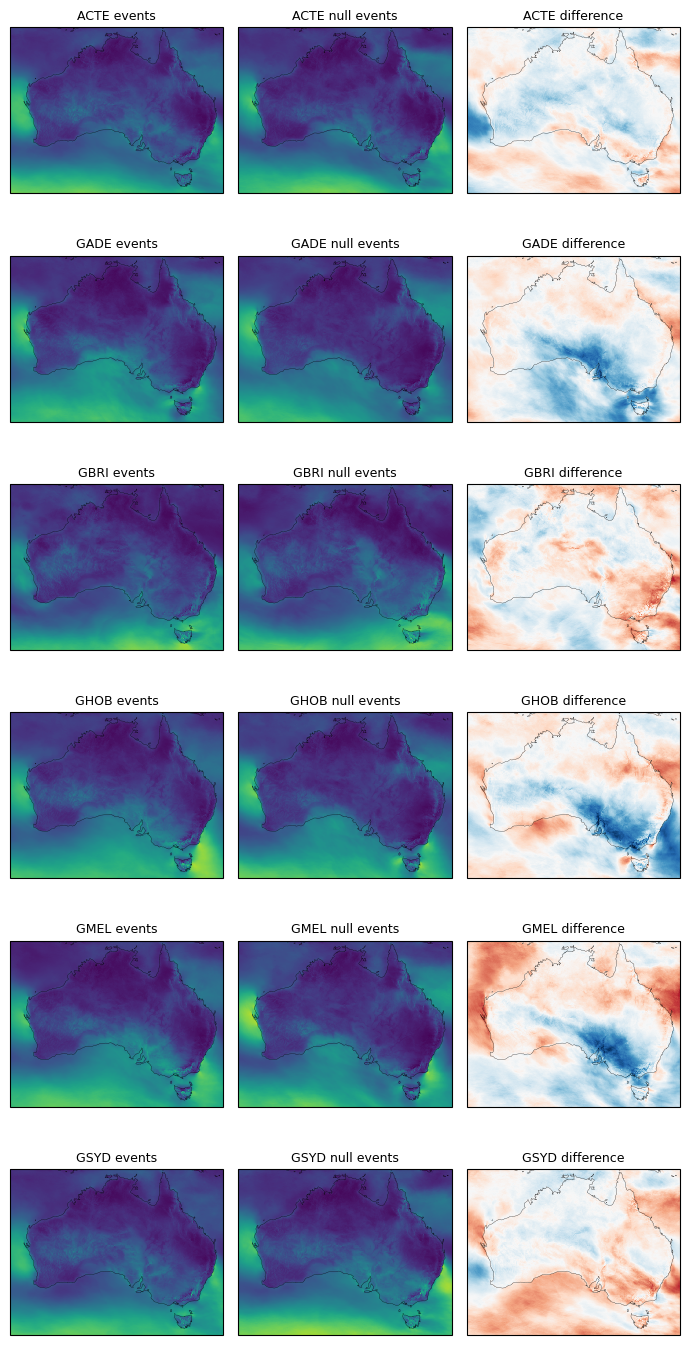

In [34]:
fig, ax = plt.subplots(6, 3, figsize=(7, 14), subplot_kw={"projection": ccrs.PlateCarree()})

for i, r in enumerate(regions[:]):
    
    composite_data[r]["events"].plot(ax=ax[i,0], vmin=0, vmax=1, add_colorbar=False)
    ax[i,0].set_title(r+" events", fontsize=9)
    
    composite_data[r]["nulls"].plot(ax=ax[i,1], vmin=0, vmax=1, add_colorbar=False)
    ax[i,1].set_title(r+" null events", fontsize=9)

    diff = composite_data[r]["events"] - composite_data[r]["nulls"]
    diff.plot(ax=ax[i,2], vmin=-0.3, vmax=0.3, cmap="RdBu", add_colorbar=False)
    ax[i,2].set_title(r+" difference", fontsize=9)

for a in ax.flatten():
    a.coastlines(lw=.2)
    a.set_xlabel("")
    a.set_xticklabels([])
    a.set_ylabel("")
    a.set_yticklabels([])

plt.tight_layout()

plt.savefig("figs/wind_capacity_factor_composites.png", format="png", dpi=200)